# Molecular prediction: fine-tuned with an unfrozen head variants against the baseline (axis-200-900)

Does pretraining change what the head predicts: the whole-axis metrics, single classes, class strata and the calibration of the probabilities? Stage shown: **fine-tuned with an unfrozen head**, i.e. the pretrained model after 10 epochs on the real training data with every parameter trainable.

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "stage_prediction"
AXIS = "axis-200-900"
STAGE = "unfrozen_head"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]
EVALUATIONS = ['test', 'test_combined', 'heldout_image', 'heldout_image_per_image']

prediction = table('prediction')
BEST = load_metadata(settings, 'stage_overview', AXIS, STAGE)['best_variant']
print('Best variant:', BEST)

Analysis: stage_prediction | axis: axis-200-900 | stage: unfrozen_head | models: 55
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}
Best variant: P3_staged_overlap


## Producing the tables this notebook reads

### Methodology

#### Implementation

`stage_prediction` collects the ranking tables of the `inference` level (the same `ranking_tables`
implementation as part 1), the per-class tables, the class-stratum tables and recomputes the calibration
from the stored logits (held-out: from the stored float16 probabilities).

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis stage_prediction > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute head metrics of every variant and of the real-only baseline

### Methodology

#### Theoretical

The complete metric set of the head (macro and micro AP, ROC AUC, AP above prevalence, macro and micro
precision, recall and F1 at 0.5, micro prevalence, Hamming loss) for the baseline and every variant, per
evaluation population, per held-out image and per class stratum, together with the calibration of the
probabilities: the levels behind the improvements reported below.

#### Implementation

`prediction` (group `all` and per held-out image; annotation retrieval, training-supported classes), `strata` and `calibration`; one value per model.

#### Figure descriptions

        Figure 1: one panel per metric and evaluation population, x = baseline and variants, violin and points = five
        repetitions. Tables: complete metric set on test + extension and on the held-out images. Figure 2: held-out
        macro AP per image. Tables: macro AP per class stratum on the held-out images; calibration.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

test + extension


metric,average_precision,micro_average_precision,roc_auc,micro_roc_auc,ap_above_prevalence,precision,recall,f1,micro_precision,micro_recall,micro_f1,micro_prevalence,hamming_loss
variant,,,,,,,,,,,,,
baseline,0.709 +/- 0.003,0.883 +/- 0.009,0.987 +/- 0.000,0.994 +/- 0.000,0.650 +/- 0.003,0.574 +/- 0.024,0.497 +/- 0.016,0.491 +/- 0.012,0.847 +/- 0.009,0.806 +/- 0.007,0.826 +/- 0.005,0.058 +/- 0.000,0.020 +/- 0.001
P0_single,0.709 +/- 0.004,0.886 +/- 0.006,0.987 +/- 0.000,0.994 +/- 0.000,0.650 +/- 0.004,0.525 +/- 0.021,0.431 +/- 0.024,0.440 +/- 0.023,0.871 +/- 0.008,0.762 +/- 0.028,0.813 +/- 0.016,0.058 +/- 0.000,0.021 +/- 0.001
P1_permutation,0.706 +/- 0.005,0.876 +/- 0.007,0.986 +/- 0.000,0.994 +/- 0.000,0.648 +/- 0.005,0.571 +/- 0.026,0.473 +/- 0.014,0.479 +/- 0.016,0.859 +/- 0.004,0.790 +/- 0.008,0.823 +/- 0.005,0.058 +/- 0.000,0.020 +/- 0.001
P2_joint_base,0.706 +/- 0.005,0.874 +/- 0.015,0.986 +/- 0.001,0.993 +/- 0.001,0.648 +/- 0.005,0.527 +/- 0.039,0.428 +/- 0.039,0.438 +/- 0.040,0.866 +/- 0.003,0.762 +/- 0.033,0.810 +/- 0.020,0.058 +/- 0.000,0.021 +/- 0.002
P2_staged_base,0.710 +/- 0.003,0.879 +/- 0.005,0.987 +/- 0.000,0.994 +/- 0.000,0.652 +/- 0.003,0.549 +/- 0.015,0.450 +/- 0.015,0.454 +/- 0.011,0.861 +/- 0.010,0.777 +/- 0.010,0.817 +/- 0.006,0.058 +/- 0.000,0.020 +/- 0.001
P3_joint_overlap,0.710 +/- 0.003,0.878 +/- 0.004,0.987 +/- 0.000,0.994 +/- 0.000,0.652 +/- 0.003,0.564 +/- 0.019,0.462 +/- 0.010,0.467 +/- 0.011,0.860 +/- 0.004,0.784 +/- 0.004,0.820 +/- 0.002,0.058 +/- 0.000,0.020 +/- 0.000
P3_staged_overlap,0.712 +/- 0.005,0.881 +/- 0.007,0.987 +/- 0.000,0.994 +/- 0.000,0.654 +/- 0.005,0.528 +/- 0.022,0.429 +/- 0.027,0.438 +/- 0.025,0.869 +/- 0.005,0.760 +/- 0.021,0.811 +/- 0.011,0.058 +/- 0.000,0.021 +/- 0.001
P4_joint_rare,0.710 +/- 0.004,0.878 +/- 0.006,0.986 +/- 0.000,0.994 +/- 0.000,0.651 +/- 0.004,0.542 +/- 0.015,0.447 +/- 0.017,0.455 +/- 0.017,0.864 +/- 0.003,0.777 +/- 0.015,0.818 +/- 0.009,0.058 +/- 0.000,0.020 +/- 0.001
P4_staged_rare,0.712 +/- 0.001,0.879 +/- 0.004,0.987 +/- 0.000,0.994 +/- 0.000,0.653 +/- 0.001,0.534 +/- 0.014,0.436 +/- 0.017,0.442 +/- 0.016,0.863 +/- 0.001,0.770 +/- 0.014,0.814 +/- 0.008,0.058 +/- 0.000,0.021 +/- 0.001


held-out images


metric,average_precision,micro_average_precision,roc_auc,micro_roc_auc,ap_above_prevalence,precision,recall,f1,micro_precision,micro_recall,micro_f1,micro_prevalence,hamming_loss
variant,,,,,,,,,,,,,
baseline,0.356 +/- 0.007,0.592 +/- 0.010,0.697 +/- 0.008,0.810 +/- 0.004,0.122 +/- 0.007,0.338 +/- 0.035,0.134 +/- 0.014,0.140 +/- 0.015,0.664 +/- 0.006,0.306 +/- 0.020,0.419 +/- 0.020,0.234 +/- 0.000,0.199 +/- 0.003
P0_single,0.343 +/- 0.008,0.579 +/- 0.006,0.694 +/- 0.010,0.808 +/- 0.005,0.109 +/- 0.008,0.302 +/- 0.051,0.127 +/- 0.016,0.131 +/- 0.019,0.642 +/- 0.014,0.296 +/- 0.024,0.405 +/- 0.022,0.234 +/- 0.000,0.203 +/- 0.003
P1_permutation,0.353 +/- 0.012,0.587 +/- 0.016,0.693 +/- 0.012,0.805 +/- 0.006,0.119 +/- 0.012,0.324 +/- 0.025,0.129 +/- 0.010,0.137 +/- 0.011,0.667 +/- 0.016,0.295 +/- 0.016,0.409 +/- 0.018,0.234 +/- 0.000,0.199 +/- 0.004
P2_joint_base,0.343 +/- 0.013,0.579 +/- 0.011,0.694 +/- 0.015,0.809 +/- 0.005,0.109 +/- 0.013,0.287 +/- 0.011,0.140 +/- 0.015,0.145 +/- 0.015,0.640 +/- 0.014,0.310 +/- 0.022,0.418 +/- 0.020,0.234 +/- 0.000,0.202 +/- 0.003
P2_staged_base,0.341 +/- 0.008,0.570 +/- 0.012,0.681 +/- 0.012,0.801 +/- 0.008,0.107 +/- 0.008,0.319 +/- 0.025,0.129 +/- 0.016,0.134 +/- 0.019,0.640 +/- 0.009,0.300 +/- 0.022,0.408 +/- 0.021,0.234 +/- 0.000,0.203 +/- 0.003
P3_joint_overlap,0.348 +/- 0.019,0.585 +/- 0.014,0.692 +/- 0.011,0.805 +/- 0.010,0.114 +/- 0.019,0.290 +/- 0.030,0.143 +/- 0.011,0.150 +/- 0.009,0.649 +/- 0.019,0.320 +/- 0.023,0.428 +/- 0.018,0.234 +/- 0.000,0.200 +/- 0.002
P3_staged_overlap,0.345 +/- 0.009,0.582 +/- 0.005,0.688 +/- 0.009,0.804 +/- 0.003,0.111 +/- 0.009,0.302 +/- 0.016,0.135 +/- 0.014,0.142 +/- 0.014,0.651 +/- 0.010,0.310 +/- 0.026,0.419 +/- 0.022,0.234 +/- 0.000,0.200 +/- 0.002
P4_joint_rare,0.350 +/- 0.005,0.586 +/- 0.004,0.695 +/- 0.006,0.806 +/- 0.001,0.117 +/- 0.005,0.311 +/- 0.044,0.144 +/- 0.011,0.154 +/- 0.011,0.654 +/- 0.010,0.318 +/- 0.016,0.428 +/- 0.015,0.234 +/- 0.000,0.199 +/- 0.003
P4_staged_rare,0.352 +/- 0.008,0.594 +/- 0.010,0.695 +/- 0.011,0.809 +/- 0.005,0.118 +/- 0.008,0.297 +/- 0.015,0.145 +/- 0.017,0.156 +/- 0.019,0.660 +/- 0.017,0.327 +/- 0.027,0.437 +/- 0.025,0.234 +/- 0.000,0.197 +/- 0.005


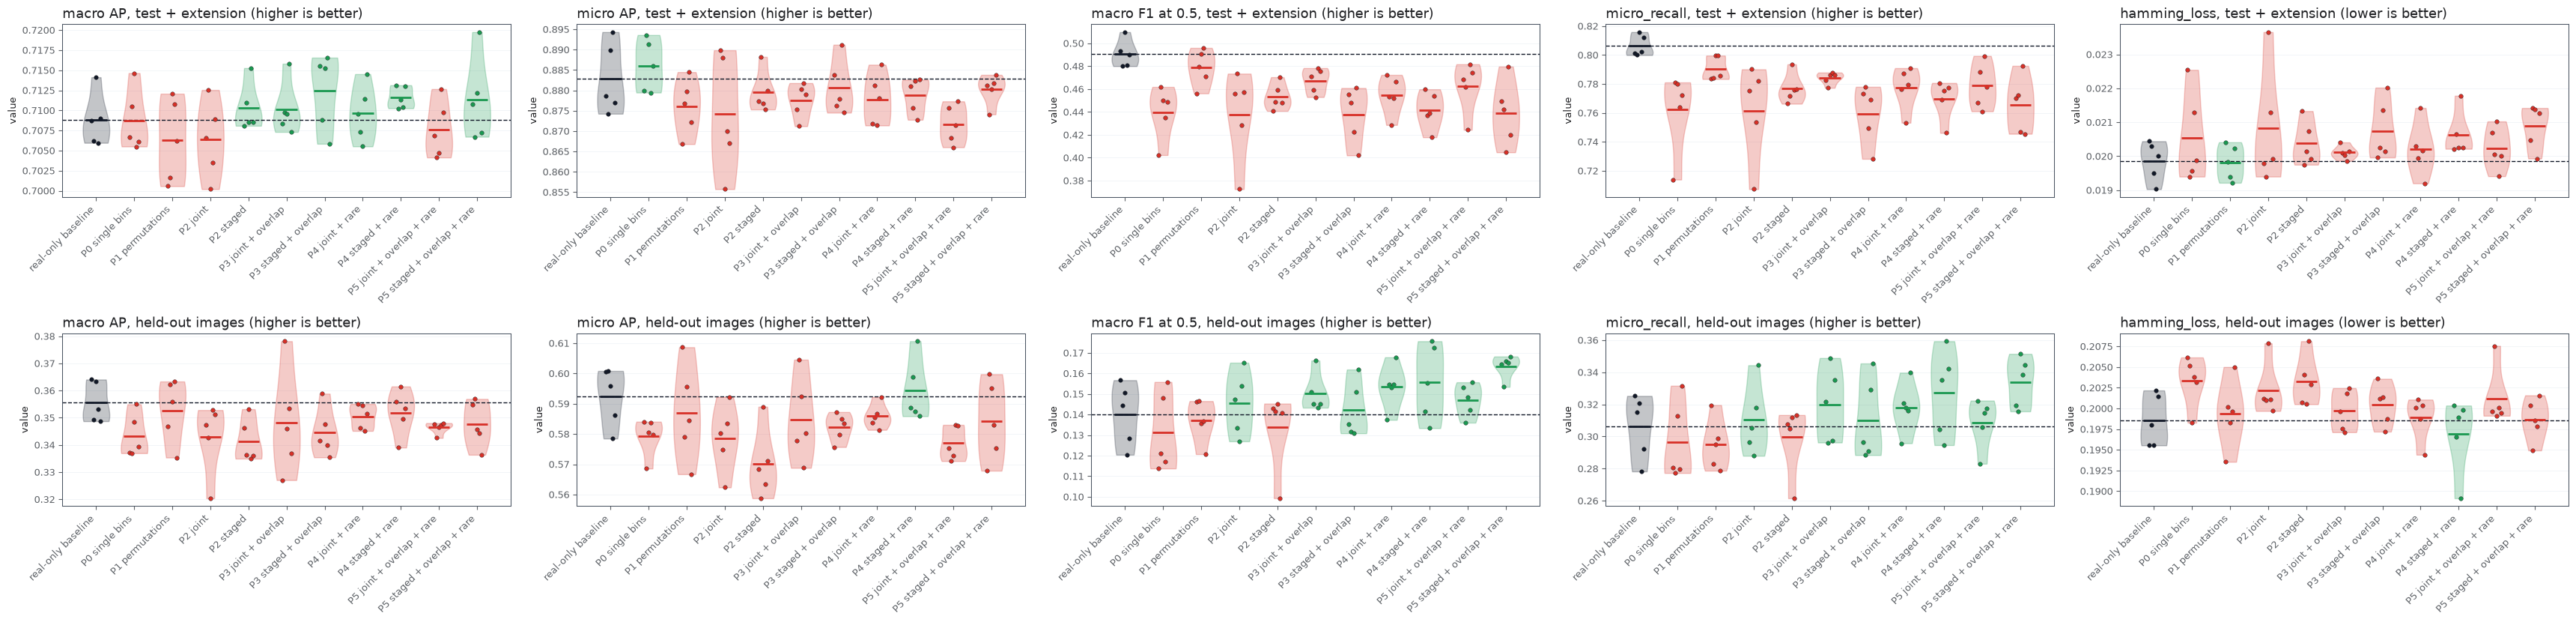

In [4]:
prediction_abs = table('prediction')
whole = prediction_abs[(prediction_abs.group == 'all') & (prediction_abs.scope == 'train_supported') & (prediction_abs.population == 'annotation_retrieval')]
panels = [(f"{SHORT.get(metric, metric)}, {EVALUATION_NAMES.get(evaluation, evaluation)}", {'metric': metric, 'evaluation': evaluation}, better(metric))
          for evaluation in ('test_combined', 'heldout_image')
          for metric in ('average_precision', 'micro_average_precision', 'f1', 'micro_recall', 'hamming_loss')]
figures.metric_panels(whole, panels=panels, group='variant', order=ABS_ORDER, labels=LABELS_ABS, baseline=BASELINE, columns=5, theme=theme);
for evaluation in ('test_combined', 'heldout_image'):
    rows = whole[whole.evaluation == evaluation]
    print(EVALUATION_NAMES.get(evaluation, evaluation))
    display(figures.comparison_table(rows, index='variant', columns='metric', baseline=BASELINE, order=ABS_ORDER,
                                     column_order=METRIC_ORDER, direction={metric: better(metric) for metric in rows.metric.unique()}))

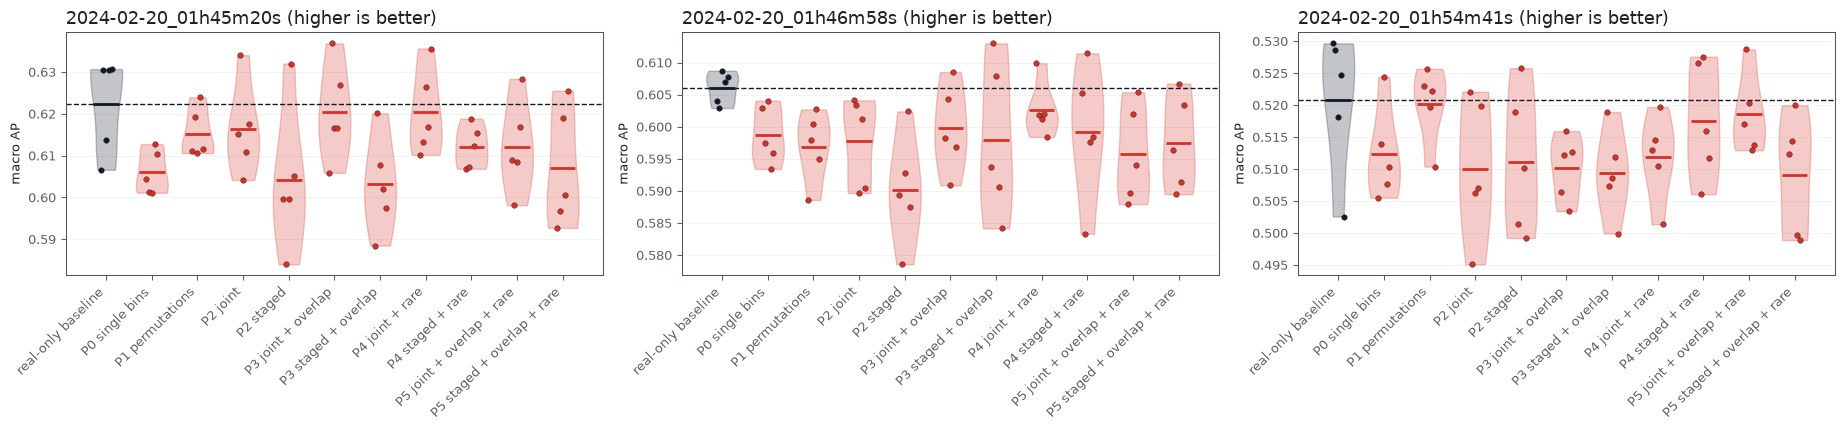

Held-out macro AP per class stratum


column,class_set | common,heldout_presence | in_heldout,heldout_presence | not_in_heldout,mz_window | 200-300,mz_window | 300-400,mz_window | 400-500,mz_window | 500-600,mz_window | 600-700,mz_window | 700-800,mz_window | 800-900,train_support | 1-9,train_support | 10-99,train_support | 100-999,train_support | 1000+
variant,,,,,,,,,,,,,,
baseline,0.356 +/- 0.007,0.356 +/- 0.007,nan +/- -,0.432 +/- 0.020,0.276 +/- 0.015,0.713 +/- 0.049,nan +/- -,nan +/- -,0.282 +/- 0.010,0.557 +/- 0.038,0.002 +/- 0.001,nan +/- -,0.713 +/- 0.049,0.355 +/- 0.011
P0_single,0.343 +/- 0.008,0.343 +/- 0.008,nan +/- -,0.417 +/- 0.021,0.287 +/- 0.013,0.651 +/- 0.032,nan +/- -,nan +/- -,0.267 +/- 0.006,0.524 +/- 0.012,0.013 +/- 0.025,nan +/- -,0.651 +/- 0.032,0.345 +/- 0.007
P1_permutation,0.353 +/- 0.012,0.353 +/- 0.012,nan +/- -,0.435 +/- 0.024,0.281 +/- 0.015,0.684 +/- 0.055,nan +/- -,nan +/- -,0.275 +/- 0.010,0.558 +/- 0.032,0.028 +/- 0.048,nan +/- -,0.684 +/- 0.055,0.352 +/- 0.013
P2_joint_base,0.343 +/- 0.013,0.343 +/- 0.013,nan +/- -,0.423 +/- 0.025,0.273 +/- 0.014,0.663 +/- 0.044,nan +/- -,nan +/- -,0.271 +/- 0.013,0.528 +/- 0.020,0.009 +/- 0.012,nan +/- -,0.663 +/- 0.044,0.344 +/- 0.014
P2_staged_base,0.341 +/- 0.008,0.341 +/- 0.008,nan +/- -,0.418 +/- 0.024,0.264 +/- 0.018,0.635 +/- 0.023,nan +/- -,nan +/- -,0.275 +/- 0.006,0.543 +/- 0.021,0.003 +/- 0.003,nan +/- -,0.635 +/- 0.023,0.344 +/- 0.009
P3_joint_overlap,0.348 +/- 0.019,0.348 +/- 0.019,nan +/- -,0.410 +/- 0.035,0.276 +/- 0.009,0.691 +/- 0.087,nan +/- -,nan +/- -,0.278 +/- 0.021,0.543 +/- 0.032,0.013 +/- 0.025,nan +/- -,0.691 +/- 0.087,0.348 +/- 0.018
P3_staged_overlap,0.345 +/- 0.009,0.345 +/- 0.009,nan +/- -,0.436 +/- 0.007,0.272 +/- 0.008,0.672 +/- 0.084,nan +/- -,nan +/- -,0.268 +/- 0.008,0.538 +/- 0.010,0.007 +/- 0.013,nan +/- -,0.672 +/- 0.084,0.345 +/- 0.006
P4_joint_rare,0.350 +/- 0.005,0.350 +/- 0.005,nan +/- -,0.429 +/- 0.022,0.275 +/- 0.011,0.718 +/- 0.041,nan +/- -,nan +/- -,0.275 +/- 0.010,0.542 +/- 0.005,0.003 +/- 0.003,nan +/- -,0.718 +/- 0.041,0.349 +/- 0.004
P4_staged_rare,0.352 +/- 0.008,0.352 +/- 0.008,nan +/- -,0.433 +/- 0.016,0.275 +/- 0.008,0.664 +/- 0.075,nan +/- -,nan +/- -,0.278 +/- 0.007,0.565 +/- 0.011,0.001 +/- 0.000,nan +/- -,0.664 +/- 0.075,0.354 +/- 0.006


Calibration (mean probability and positive rate are levels, not scores)


column,brier_score | heldout_image,brier_score | test_combined,expected_calibration_error | heldout_image,expected_calibration_error | test_combined,mean_probability | heldout_image,mean_probability | test_combined,positive_rate | heldout_image,positive_rate | test_combined
variant,,,,,,,,
baseline,0.005 +/- 0.000,0.015 +/- 0.000,0.003 +/- 0.000,0.006 +/- 0.000,0.006 +/- 0.000,0.057 +/- 0.001,0.008 +/- 0.000,0.058 +/- 0.000
P0_single,0.005 +/- 0.000,0.015 +/- 0.001,0.004 +/- 0.000,0.009 +/- 0.001,0.006 +/- 0.000,0.051 +/- 0.002,0.008 +/- 0.000,0.058 +/- 0.000
P1_permutation,0.005 +/- 0.000,0.015 +/- 0.000,0.003 +/- 0.000,0.008 +/- 0.001,0.006 +/- 0.000,0.055 +/- 0.001,0.008 +/- 0.000,0.058 +/- 0.000
P2_joint_base,0.005 +/- 0.000,0.016 +/- 0.001,0.003 +/- 0.000,0.010 +/- 0.002,0.006 +/- 0.000,0.052 +/- 0.002,0.008 +/- 0.000,0.058 +/- 0.000
P2_staged_base,0.005 +/- 0.000,0.015 +/- 0.000,0.004 +/- 0.000,0.009 +/- 0.000,0.006 +/- 0.000,0.053 +/- 0.001,0.008 +/- 0.000,0.058 +/- 0.000
P3_joint_overlap,0.005 +/- 0.000,0.015 +/- 0.000,0.003 +/- 0.000,0.008 +/- 0.000,0.006 +/- 0.000,0.054 +/- 0.000,0.008 +/- 0.000,0.058 +/- 0.000
P3_staged_overlap,0.005 +/- 0.000,0.015 +/- 0.001,0.003 +/- 0.000,0.009 +/- 0.001,0.006 +/- 0.000,0.052 +/- 0.002,0.008 +/- 0.000,0.058 +/- 0.000
P4_joint_rare,0.005 +/- 0.000,0.015 +/- 0.001,0.003 +/- 0.000,0.009 +/- 0.001,0.006 +/- 0.000,0.053 +/- 0.001,0.008 +/- 0.000,0.058 +/- 0.000
P4_staged_rare,0.005 +/- 0.000,0.015 +/- 0.001,0.003 +/- 0.000,0.009 +/- 0.001,0.006 +/- 0.000,0.053 +/- 0.001,0.008 +/- 0.000,0.058 +/- 0.000


In [5]:
per_image = prediction_abs[(prediction_abs.group != 'all') & (prediction_abs.scope == 'train_supported')
                           & (prediction_abs.population == 'annotation_retrieval') & (prediction_abs.metric == 'average_precision')]
datasets = sorted(per_image.group.unique())
figure, axes = plt.subplots(1, len(datasets), figsize=(6.2 * len(datasets), 4.4), dpi=theme.figure_dpi)
for ax, dataset in zip(np.atleast_1d(axes), datasets):
    figures.value_violins(per_image[per_image.group == dataset], value='value', group='variant', order=ABS_ORDER, labels=LABELS_ABS,
                          baseline=BASELINE, direction='higher', ylabel='macro AP', title=dataset, ax=ax, theme=theme)
figure.tight_layout()
plt.show()
strata_abs = table('strata')
strata_abs = strata_abs[(strata_abs.group == 'all') & (strata_abs.scope == 'train_supported') & (strata_abs.population == 'annotation_retrieval')
                        & (strata_abs.metric == 'average_precision') & (strata_abs.evaluation == 'heldout_image')]
strata_abs = strata_abs.assign(column=strata_abs.grouping + ' | ' + strata_abs.stratum.astype(str))
print('Held-out macro AP per class stratum')
display(figures.comparison_table(strata_abs, index='variant', columns='column', baseline=BASELINE, order=ABS_ORDER,
                                 direction={column: 'higher' for column in strata_abs.column.unique()}))
calibration_abs = table('calibration').melt(id_vars=['repetition', 'variant', 'evaluation'], value_vars=['expected_calibration_error', 'brier_score', 'mean_probability', 'positive_rate'], var_name='metric')
calibration_abs['column'] = calibration_abs.metric + ' | ' + calibration_abs.evaluation
print('Calibration (mean probability and positive rate are levels, not scores)')
display(figures.comparison_table(calibration_abs, index='variant', columns='column', baseline=BASELINE, order=ABS_ORDER,
                                 direction={column: 'lower' for column in calibration_abs.column.unique() if column.split(' | ')[0] in ('expected_calibration_error', 'brier_score')}))

### Remarks

- macro AP, test_combined: baseline 0.7088; others 0.7063-0.7124; 6 of 10 better than the baseline; best P3 staged + overlap (0.7124), worst P1 permutations (0.7063).
- micro AP, test_combined: baseline 0.8828; others 0.8717-0.886; 1 of 10 better than the baseline; best P0 single bins (0.886), worst P5 joint + overlap + rare (0.8717).
- micro recall at 0.5, test_combined: baseline 0.8063; others 0.7596-0.7905; 0 of 10 better than the baseline; best P1 permutations (0.7905), worst P3 staged + overlap (0.7596).
- macro AP, heldout_image: baseline 0.3557; others 0.3413-0.3527; 0 of 10 better than the baseline; best P1 permutations (0.3527), worst P2 staged (0.3413).
- micro AP, heldout_image: baseline 0.5924; others 0.5701-0.5943; 1 of 10 better than the baseline; best P4 staged + rare (0.5943), worst P2 staged (0.5701).
- micro recall at 0.5, heldout_image: baseline 0.3063; others 0.295-0.3339; 7 of 10 better than the baseline; best P5 staged + overlap + rare (0.3339), worst P1 permutations (0.295).

### Notes

## Whole-axis head metrics

### Methodology

#### Theoretical

The complete metric set of part 1_08 for every variant and the baseline; macro AP weights every class
equally, micro AP every entry.

#### Implementation

`prediction` rows with scope `train_supported`, group `all`, ranking population `annotation_retrieval`.

#### Figure descriptions

One panel per metric; x = variant, colour = evaluation (test + extension, pooled held-out images), one point
per repetition. The table gives mean +/- SD.

evaluation              heldout_image                                                                                                                                                  \
metric            ap_above_prevalence average_precision               f1     hamming_loss micro_average_precision         micro_f1  micro_precision micro_prevalence     micro_recall   
variant                                                                                                                                                                                 
baseline              0.122 +/- 0.007   0.356 +/- 0.007  0.140 +/- 0.015  0.199 +/- 0.003         0.592 +/- 0.010  0.419 +/- 0.020  0.664 +/- 0.006  0.234 +/- 0.000  0.306 +/- 0.020   
P0_single             0.109 +/- 0.008   0.343 +/- 0.008  0.131 +/- 0.019  0.203 +/- 0.003         0.579 +/- 0.006  0.405 +/- 0.022  0.642 +/- 0.014  0.234 +/- 0.000  0.296 +/- 0.024   
P1_permutation        0.119 +/- 0.012   0.353 +/- 0.012  0.137 +/- 0.011  0.199 +/- 0.004         0.587 +/- 0.016  0.409 +/- 0.018  0.667 +/- 0.016  0.234 +/- 0.000  0.295 +/- 0.016   
P2_joint_base         0.109 +/- 0.013   0.343 +/- 0.013  0.145 +/- 0.015  0.202 +/- 0.003         0.579 +/- 0.011  0.418 +/- 0.020  0.640 +/- 0.014  0.234 +/- 0.000  0.310 +/- 0.022   
P2_staged_base        0.107 +/- 0.008   0.341 +/- 0.008  0.134 +/- 0.019  0.203 +/- 0.003         0.570 +/- 0.012  0.408 +/- 0.021  0.640 +/- 0.009  0.234 +/- 0.000  0.300 +/- 0.022   
P3_joint_overlap      0.114 +/- 0.019   0.348 +/- 0.019  0.150 +/- 0.009  0.200 +/- 0.002         0.585 +/- 0.014  0.428 +/- 0.018  0.649 +/- 0.019  0.234 +/- 0.000  0.320 +/- 0.023   
P3_staged_overlap     0.111 +/- 0.009   0.345 +/- 0.009  0.142 +/- 0.014  0.200 +/- 0.002         0.582 +/- 0.005  0.419 +/- 0.022  0.651 +/- 0.010  0.234 +/- 0.000  0.310 +/- 0.026   
P4_joint_rare         0.117 +/- 0.005   0.350 +/- 0.005  0.154 +/- 0.011  0.199 +/- 0.003         0.586 +/- 0.004  0.428 +/- 0.015  0.654 +/- 0.010  0.234 +/- 0.000  0.318 +/- 0.016   
P4_staged_rare        0.118 +/- 0.008   0.352 +/- 0.008  0.156 +/- 0.019  0.197 +/- 0.005         0.594 +/- 0.010  0.437 +/- 0.025  0.660 +/- 0.017  0.234 +/- 0.000  0.327 +/- 0.027   
P5_joint_all          0.113 +/- 0.002   0.346 +/- 0.002  0.147 +/- 0.008  0.201 +/- 0.004         0.577 +/- 0.006  0.418 +/- 0.016  0.646 +/- 0.013  0.234 +/- 0.000  0.309 +/- 0.016   
P5_staged_all         0.114 +/- 0.008   0.348 +/- 0.008  0.163 +/- 0.006  0.199 +/- 0.003         0.584 +/- 0.013  0.440 +/- 0.011  0.647 +/- 0.020  0.234 +/- 0.000  0.334 +/- 0.016   

evaluation                                                                                  test_combined                                                                              \
metric               micro_roc_auc        precision           recall          roc_auc ap_above_prevalence average_precision               f1     hamming_loss micro_average_precision   
variant                                                                                                                                                                                 
baseline           0.810 +/- 0.004  0.338 +/- 0.035  0.134 +/- 0.014  0.697 +/- 0.008     0.650 +/- 0.003   0.709 +/- 0.003  0.491 +/- 0.012  0.020 +/- 0.001         0.883 +/- 0.009   
P0_single          0.808 +/- 0.005  0.302 +/- 0.051  0.127 +/- 0.016  0.694 +/- 0.010     0.650 +/- 0.004   0.709 +/- 0.004  0.440 +/- 0.023  0.021 +/- 0.001         0.886 +/- 0.006   
P1_permutation     0.805 +/- 0.006  0.324 +/- 0.025  0.129 +/- 0.010  0.693 +/- 0.012     0.648 +/- 0.005   0.706 +/- 0.005  0.479 +/- 0.016  0.020 +/- 0.001         0.876 +/- 0.007   
P2_joint_base      0.809 +/- 0.005  0.287 +/- 0.011  0.140 +/- 0.015  0.694 +/- 0.015     0.648 +/- 0.005   0.706 +/- 0.005  0.438 +/- 0.040  0.021 +/- 0.002         0.874 +/- 0.015   
P2_staged_base     0.801 +/- 0.008  0.319 +/- 0.025  0.129 +/- 0.016  0.681 +/- 0.012     0.652 +/- 0.003   0.710 

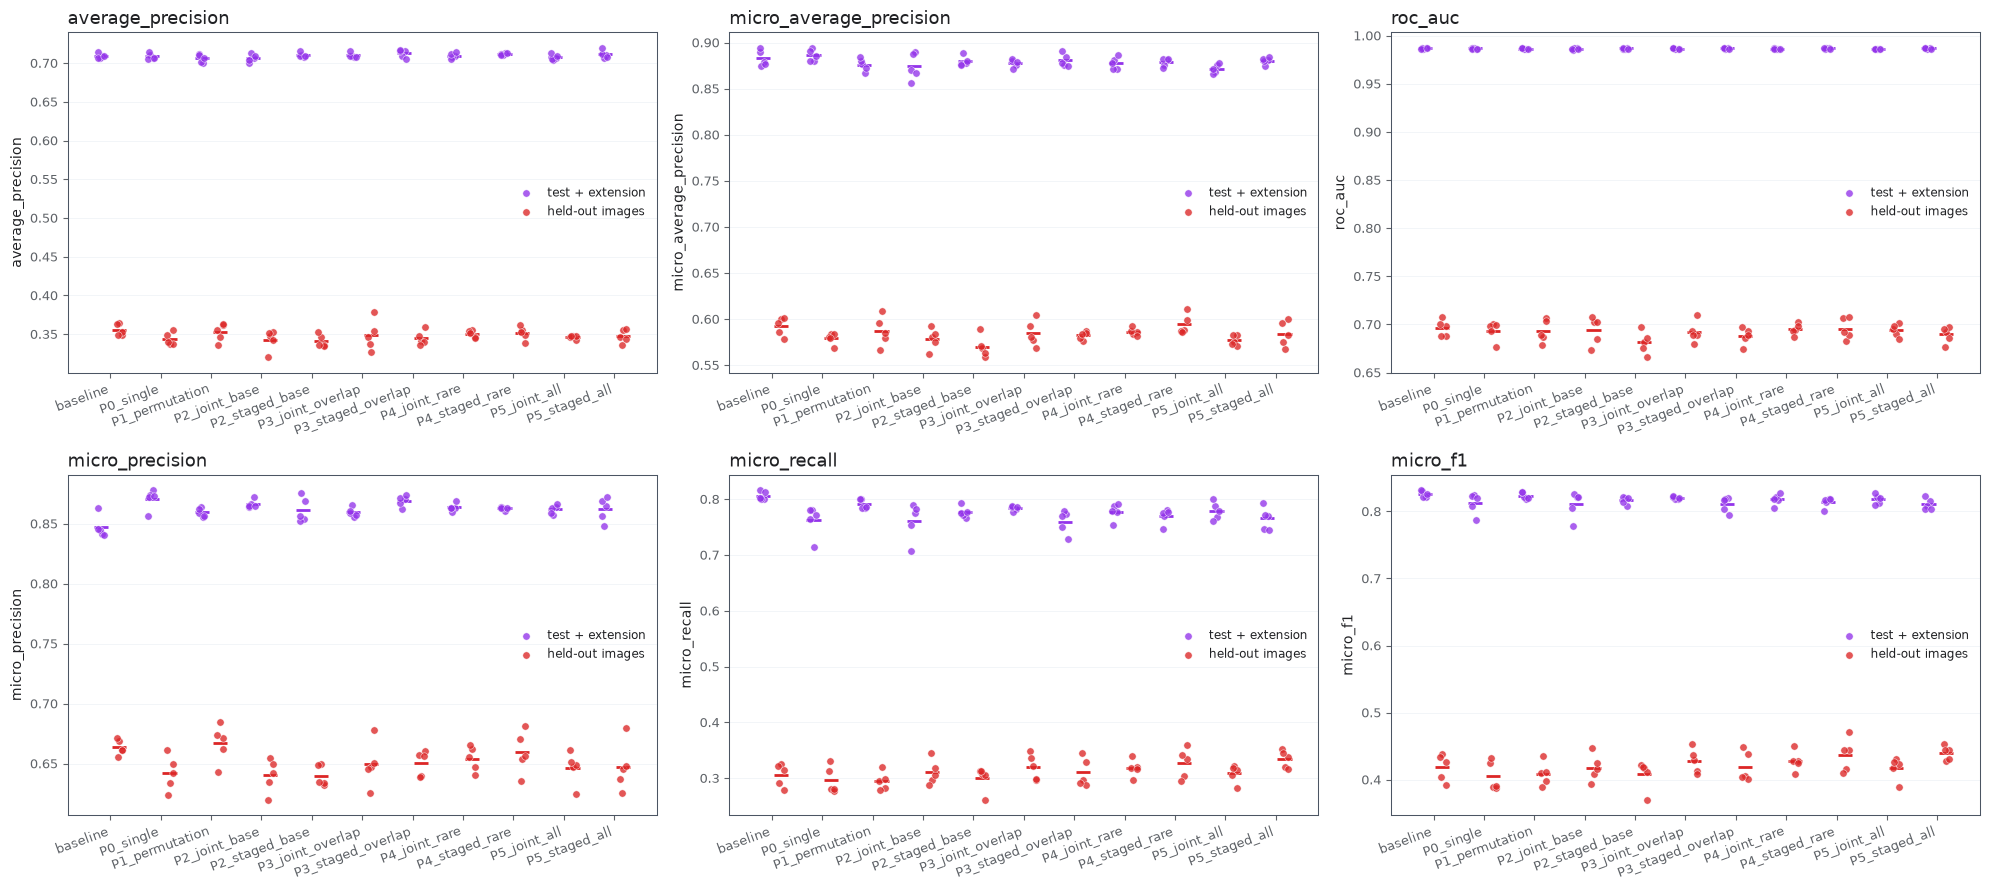

In [6]:
whole = prediction[(prediction.group == 'all') & (prediction.scope == 'train_supported') & (prediction.population == 'annotation_retrieval')]
shown = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_precision', 'micro_recall', 'micro_f1']
figure, axes = plt.subplots(2, 3, figsize=(20, 9), dpi=theme.figure_dpi)
for ax, metric in zip(axes.flat, shown):
    figures.repetition_points(whole[whole.metric == metric], value='value', group='variant', hue='evaluation', order=ORDER,
                              hue_order=['test_combined', 'heldout_image'], colors=POPULATION_COLORS, ylabel=metric, title=metric, ax=ax, theme=theme)
figure.tight_layout()
rows = whole[whole.evaluation.isin(['test_combined', 'heldout_image'])]
grouped = rows.groupby(['variant', 'evaluation', 'metric']).value
cells = (grouped.mean().map('{:.3f}'.format) + ' +/- ' + grouped.std().map('{:.3f}'.format)).unstack(['evaluation', 'metric'])
display(cells.reindex(ORDER))

### Remarks

- average_precision, test+ext: baseline 0.709, variants 0.706-0.712.
- micro_average_precision, test+ext: baseline 0.883, variants 0.872-0.886.
- micro_recall, test+ext: baseline 0.806, variants 0.76-0.79.
- micro_precision, test+ext: baseline 0.847, variants 0.859-0.871.
- average_precision, held-out: baseline 0.356, variants 0.341-0.353.
- micro_average_precision, held-out: baseline 0.592, variants 0.57-0.594.
- micro_recall, held-out: baseline 0.306, variants 0.295-0.334.
- micro_precision, held-out: baseline 0.664, variants 0.64-0.667.
- AP above prevalence (macro AP minus the class prevalence; 0 = random ranking), held-out: baseline 0.122, variants 0.107-0.119. Pooled held-out macro AP is inflated by the high prevalence of the few held-out classes, so it must be read against this baseline of chance.

### Notes

## Head metrics per held-out image

### Methodology

#### Theoretical

Per-image metrics avoid the pooling artefact of incomplete annotations (part 1_08) and show whether a
variant's effect is consistent across new images.

#### Implementation

`prediction` rows with evaluation `heldout_image` and a single image as group.

#### Figure descriptions

No figure; repetition means of macro AP and micro AP per variant and image.

In [7]:
per_image = prediction[(prediction.evaluation == 'heldout_image') & (prediction.group != 'all') & (prediction.scope == 'train_supported')
                       & (prediction.population == 'annotation_retrieval') & prediction.metric.isin(['average_precision', 'micro_average_precision'])]
display(per_image.groupby(['variant', 'metric', 'group']).value.mean().unstack(['metric', 'group']).reindex(ORDER).round(3))

metric               average_precision                                           micro_average_precision                                          
group             2024-02-20_01h45m20s 2024-02-20_01h46m58s 2024-02-20_01h54m41s    2024-02-20_01h45m20s 2024-02-20_01h46m58s 2024-02-20_01h54m41s
variant                                                                                                                                           
baseline                         0.622                0.606                0.521                   0.743                0.835                0.836
P0_single                        0.606                0.599                0.512                   0.744                0.842                0.829
P1_permutation                   0.615                0.597                0.520                   0.740                0.831                0.827
P2_joint_base                    0.616                0.598                0.510                   0.753                0.830                0.834
P2_staged_base                   0.604                0.590                0.511                   0.724                0.821                0.831
P3_joint_overlap                 0.621                0.600                0.510                   0.744                0.836                0.829
P3_staged_overlap                0.603                0.598                0.509                   0.732                0.827                0.830
P4_joint_rare                    0.620                0.603                0.512                   0.748                0.825                0.831
P4_staged_rare                   0.612                0.599                0.518                   0.745                0.834                0.830
P5_joint_all                     0.612                0.596                0.519                   0.741                0.825                0.829
P5_staged_all                    0.607                0.597                0.509                   0.736                0.825                0.829

### Remarks

- Per-image macro AP, baseline: 01h45m20s 0.622, 01h46m58s 0.606, 01h54m41s 0.521; variants: 01h45m20s 0.603-0.621, 01h46m58s 0.59-0.603, 01h54m41s 0.509-0.52.

### Notes

## Improvement of single classes

### Methodology

#### Theoretical

For every eligible class the paired AP improvement is averaged over repetitions. A Wilcoxon signed-rank test
over classes (at least 10 non-zero class means) asks whether the median class improves; it treats classes as
units and is descriptive, because classes share the model and are not independent.

#### Implementation

`class_improvements` (per class, variant, evaluation and metric; with training positives and class set) and
`class_tests` (median improvement, fraction of improved classes, Wilcoxon statistic and p value).

#### Figure descriptions

Scatter for the best variant: x = training positives of the class (log), y = mean AP improvement, colour =
class set; one panel per evaluation. The table lists the class tests of every variant.

improved_fraction               median_improvement               wilcoxon_p_value              
evaluation            heldout_image test_combined      heldout_image test_combined    heldout_image test_combined
variant                                                                                                          
P0_single                    0.4118        0.5512            -0.0076        0.0005           0.2247        0.0324
P1_permutation               0.5294        0.3780             0.0006       -0.0009           0.6777        0.0000
P2_joint_base                0.2941        0.4134            -0.0021       -0.0010           0.0797        0.0003
P2_staged_base               0.2941        0.5236            -0.0081        0.0002           0.0079        0.0087
P3_joint_overlap             0.2353        0.4941            -0.0043       -0.0000           0.0202        0.0733
P3_staged_overlap            0.2353        0.5374            -0.0103        0.0005           0.0129        0.0000
P4_joint_rare                0.4706        0.5177            -0.0007        0.0002           0.4586        0.0519
P4_staged_rare               0.4706        0.5669            -0.0002        0.0007           0.5791        0.0000
P5_joint_all                 0.4118        0.4429            -0.0055       -0.0004           0.1324        0.2072
P5_staged_all                0.2941        0.5551            -0.0078        0.0007           0.0448        0.0000

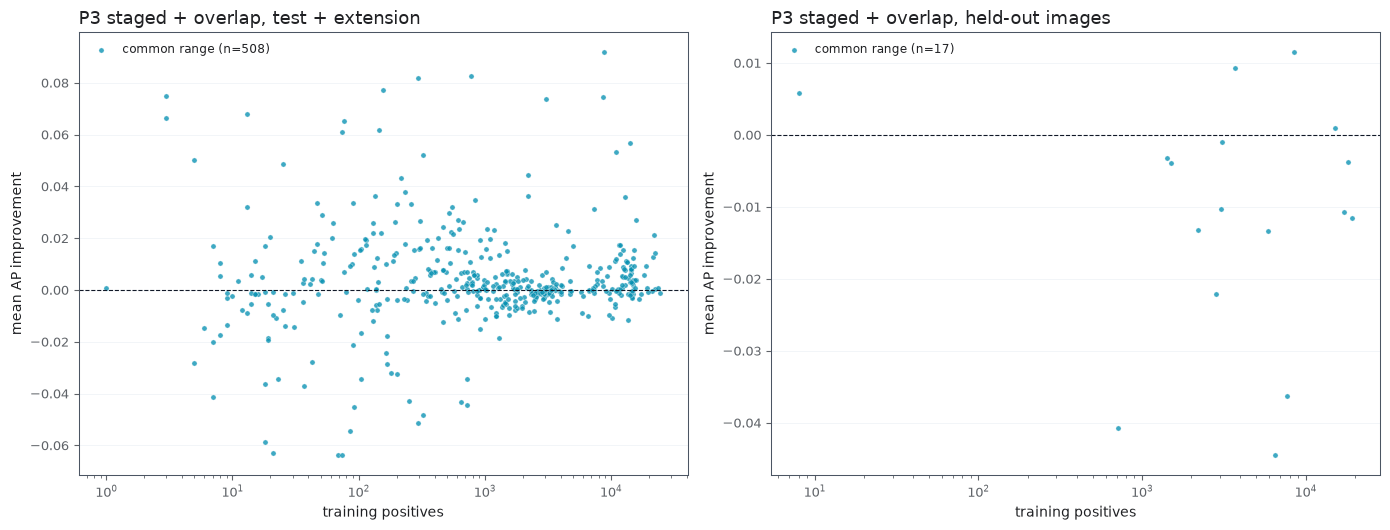

In [8]:
classes = table('class_improvements')
figure, axes = plt.subplots(1, 2, figsize=(14, 5.4), dpi=theme.figure_dpi)
for ax, evaluation in zip(axes, ['test_combined', 'heldout_image']):
    rows = classes[(classes.variant == BEST) & (classes.metric == 'average_precision') & (classes.evaluation == evaluation)]
    figures.paired_scatter(rows, x='train_positives', y='mean', hue='class_set', hue_order=sorted(rows.class_set.dropna().unique()),
                           xlabel='training positives', ylabel='mean AP improvement', title=f'{VARIANT_LABELS[BEST]}, {EVALUATION_NAMES[evaluation]}',
                           diagonal=False, ax=ax, theme=theme)
    ax.set_xscale('log')
    ax.axhline(0.0, color=theme.baseline_color, linestyle='--', linewidth=0.8)
figure.tight_layout()
tests = table('class_tests')
tests = tests[tests.metric == 'average_precision']
display(tests.pivot_table(index='variant', columns='evaluation', values=['median_improvement', 'improved_fraction', 'wilcoxon_p_value']).reindex(VARIANTS).round(4))

### Remarks

- held-out: fraction of classes with a positive mean AP improvement 0.24-0.53 across variants; median class improvement -0.0103 to 0.000605; Wilcoxon p < 0.05 for 4 of 10 variants (direction given by the median).
- test+ext: fraction of classes with a positive mean AP improvement 0.38-0.57 across variants; median class improvement -0.000983 to 0.000732; Wilcoxon p < 0.05 for 7 of 10 variants (direction given by the median).

### Notes

## Improvement per class stratum

### Methodology

#### Theoretical

Strata of part 1_10: training frequency (rare / medium / frequent), training support buckets, m/z window,
class set and presence in the held-out images. The complete metric set is recomputed per stratum, so a
stratum mean is not an average of per-class values.

#### Implementation

`strata_improvements`: summaries of the paired improvements; the evaluation column encodes
`population|grouping|stratum`.

#### Figure descriptions

Forest plot of the macro-AP improvement per frequency stratum (rows = variants; panels = stratum x
evaluation). The table lists every stratum for test + extension.

column,class_set=common,frequency=frequent,frequency=medium,frequency=rare,heldout_presence=in_heldout,heldout_presence=not_in_heldout,mz_window=200-300,mz_window=300-400,mz_window=400-500,mz_window=500-600,mz_window=600-700,mz_window=700-800,mz_window=800-900,train_support=1-9,train_support=10-99,train_support=100-999,train_support=1000+
variant,,,,,,,,,,,,,,,,,
P0_single,"-0.000107 [-0.0036, 0.00338] (+2/-3)","0.00146 [-0.00203, 0.00495] (+3/-2)","-0.00748 [-0.0145, -0.000445] (+1/-4)","-0.0116 [-0.0213, -0.00189] (+0/-5)","-0.00511 [-0.0256, 0.0154] (+2/-3)","6.64e-05 [-0.00291, 0.00305] (+2/-3)","-0.00548 [-0.00922, -0.00174] (+0/-5)","-0.000552 [-0.00673, 0.00563] (+1/-4)","-0.00115 [-0.0119, 0.00962] (+3/-2)","-0.000112 [-0.00858, 0.00835] (+2/-3)","0.00341 [-0.00477, 0.0116] (+3/-2)","0.00219 [-0.00344, 0.00783] (+3/-2)","0.00512 [-0.00297, 0.0132] (+4/-1)","-0.0116 [-0.0213, -0.00189] (+0/-5)","-0.00748 [-0.0145, -0.000445] (+1/-4)","0.00177 [-0.00429, 0.00782] (+3/-2)","0.00131 [-0.0029, 0.00551] (+3/-2)"
P1_permutation,"-0.00253 [-0.00845, 0.00338] (+1/-4)","-0.00133 [-0.00698, 0.00432] (+1/-4)","-0.0119 [-0.0284, 0.00471] (+1/-4)","0.00492 [-0.01, 0.0199] (+3/-2)","-0.00448 [-0.0199, 0.0109] (+1/-4)","-0.00246 [-0.00813, 0.0032] (+1/-4)","-0.00526 [-0.0146, 0.0041] (+1/-4)","-0.0017 [-0.00699, 0.00359] (+2/-3)","-0.00382 [-0.0166, 0.00893] (+2/-3)","-0.00382 [-0.0148, 0.00715] (+2/-3)","-6.61e-05 [-0.0116, 0.0114] (+3/-2)","-0.00337 [-0.00735, 0.000617] (+1/-4)","0.00105 [-0.00929, 0.0114] (+3/-2)","0.00492 [-0.01, 0.0199] (+3/-2)","-0.0119 [-0.0284, 0.00471] (+1/-4)","0.000354 [-0.0113, 0.012] (+2/-3)","-0.00215 [-0.00706, 0.00276] (+2/-3)"
P2_joint_base,"-0.00244 [-0.0116, 0.00668] (+1/-4)","-0.000854 [-0.00881, 0.0071] (+1/-4)","-0.00955 [-0.0307, 0.0116] (+2/-3)","-0.0157 [-0.0421, 0.0107] (+1/-4)","-0.0108 [-0.0308, 0.00932] (+1/-4)","-0.00215 [-0.0109, 0.00661] (+2/-3)","-0.00497 [-0.0103, 0.000343] (+1/-4)","-0.00227 [-0.0118, 0.00722] (+2/-3)","-0.00593 [-0.0168, 0.00498] (+2/-3)","-0.00375 [-0.0162, 0.00869] (+2/-3)","-0.000275 [-0.0123, 0.0118] (+2/-3)","-0.00135 [-0.0197, 0.017] (+3/-2)","0.00136 [-0.0107, 0.0134] (+4/-1)","-0.0157 [-0.0421, 0.0107] (+1/-4)","-0.00955 [-0.0307, 0.0116] (+2/-3)","-0.00122 [-0.0107, 0.00825] (+2/-3)","-0.000676 [-0.00801, 0.00665] (+2/-3)"
P2_staged_base,"0.00151 [-0.00557, 0.00858] (+2/-3)","0.00303 [-0.00389, 0.00995] (+3/-2)","-0.00709 [-0.0171, 0.00292] (+1/-4)","-0.00336 [-0.0315, 0.0248] (+2/-3)","0.00371 [-0.0134, 0.0209] (+3/-2)","0.00143 [-0.00547, 0.00833] (+2/-3)","-0.00201 [-0.00853, 0.00451] (+1/-4)","0.000972 [-0.0067, 0.00865] (+2/-3)","-0.000789 [-0.0143, 0.0128] (+3/-2)","0.00148 [-0.00517, 0.00812] (+4/-1)","0.00117 [-0.0084, 0.0107] (+3/-2)","0.00471 [-0.0078, 0.0172] (+4/-1)","0.00511 [-0.00866, 0.0189] (+4/-1)","-0.00336 [-0.0315, 0.0248] (+2/-3)","-0.00709 [-0.0171, 0.00292] (+1/-4)","0.00642 [-0.00512, 0.018] (+4/-1)","0.00137 [-0.0037, 0.00643] (+3/-2)"
P3_joint_overlap,"0.00138 [-0.00553, 0.00829] (+2/-3)","0.00229 [-0.0033, 0.00788] (+3/-2)","-0.00312 [-0.0178, 0.0116] (+1/-4)","-0.00434 [-0.027, 0.0183] (+3/-2)","-0.00431 [-0.0211, 0.0124] (+1/-4)","0.00157 [-0.00521, 0.00836] (+2/-3)","-0.00235 [-0.0106, 0.00594] (+2/-3)","0.000647 [-0.00753, 0.00883] (+3/-2)","0.000512 [-0.0203, 0.0213] (+3/-2)","-0.000935 [-0.00617, 0.0043] (+3/-2)","0.00107 [-0.00807, 0.0102] (+3/-2)","0.0064 [0.000286, 0.0125] (+4/-1)","0.00397 [-0.00382, 0.0118] (+2/-3)","-0.00434 [-0.027, 0.0183] (+3/-2)","-0.00312 [-0.0178, 0.0116] (+1/-4)","0.00571 [-0.00438, 0.0158] (+4/-1)","0.000608 [-0.00392, 0.00514] (+2/-3)"
P3_staged_overlap,"0.00362 [-0.00294, 0.0102] (+4/-1)","0.00424 [-0.00181, 0.0103] (+4/-1)","-0.000747 [-0.0157, 0.0142] (+1/-4)","0.00571 [-0.0226, 0.034] (+3/-2)","0.00165 [-0.0262, 0.0295] (+4/-1)","0.00369 [-0.00253, 0.00991] (+4/-1)","-0.00108 [-0.0078, 0.00564] (+2/-3)","0.00348 [-0.00345, 0.0104] (+3/-2)","0.00658 [-0.00931, 0.0225] (+3/-2)","0.00876 [0.0

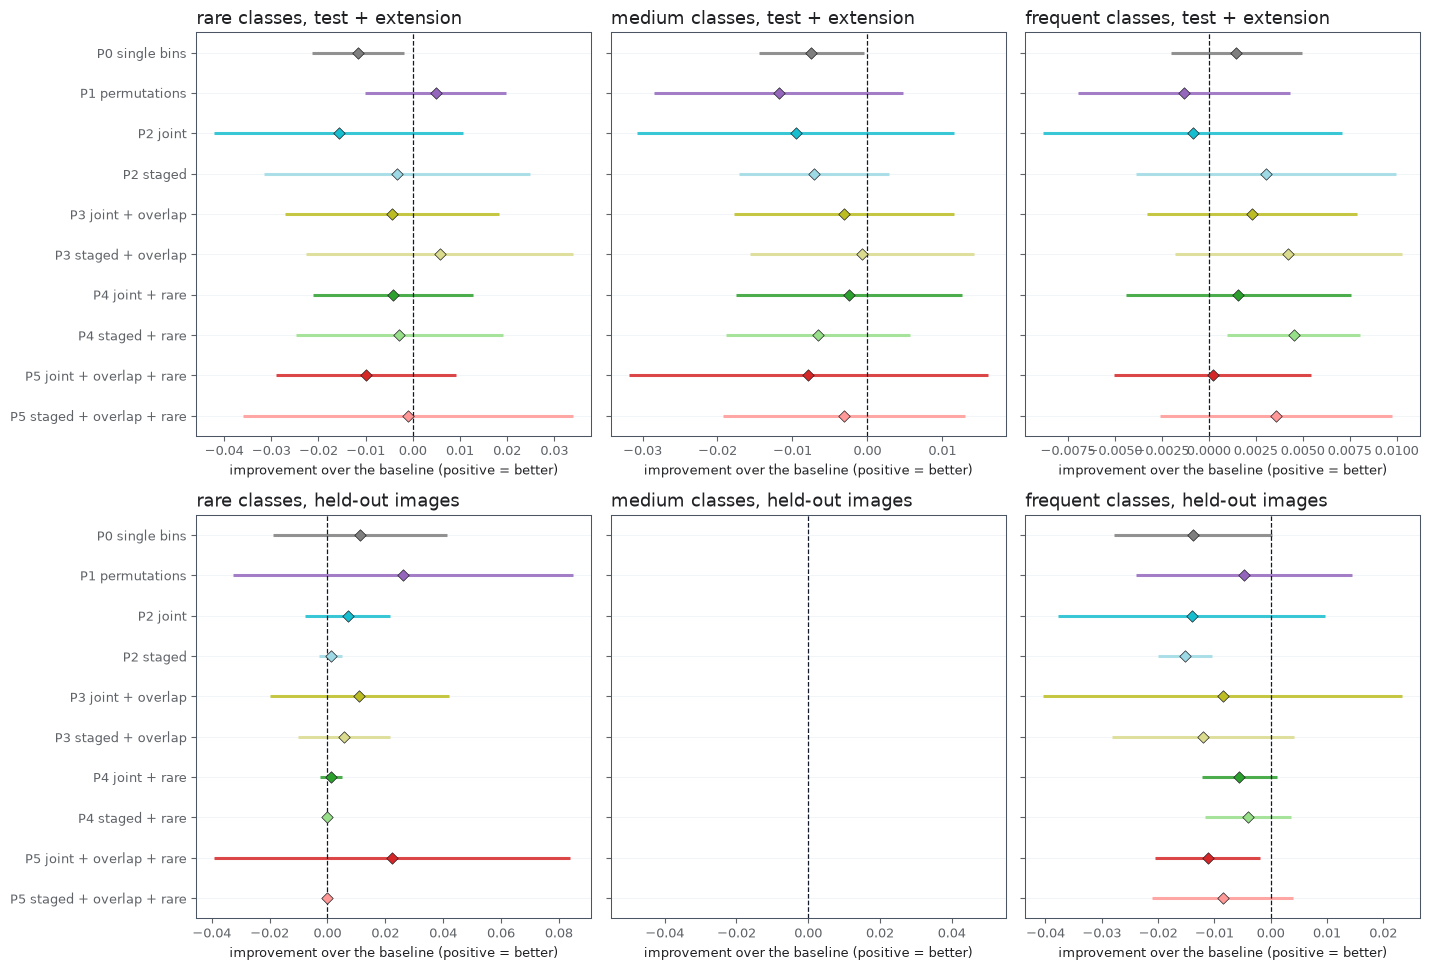

In [9]:
strata = table('strata_improvements')
strata[['population_name', 'grouping', 'stratum']] = strata.evaluation.str.split('|', expand=True)
strata = strata[(strata.metric == 'average_precision') & (strata.ranking == 'annotation_retrieval')]
panels = [(f'{stratum} classes, {EVALUATION_NAMES[population]}', {'population_name': population, 'grouping': 'frequency', 'stratum': stratum})
          for population in ['test_combined', 'heldout_image'] for stratum in ['rare', 'medium', 'frequent']]
figures.improvement_forest(strata, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS, columns=3, theme=theme);
shown = strata[strata.population_name == 'test_combined']
display(shown.assign(result=interval(shown), column=shown.grouping + '=' + shown.stratum)
        .pivot_table(index='variant', columns='column', values='result', aggfunc='first').reindex(VARIANTS))

### Remarks

- frequent classes, held-out: mean improvement -0.0153 to -0.00402; above zero: none; below: P2 staged, P5 joint + overlap + rare.
- rare classes, held-out: mean improvement -0.000262 to 0.0261; above zero: none; below: none.
- frequent classes, test+ext: mean improvement -0.00133 to 0.00451; above zero: P4 staged + rare; below: none.
- medium classes, test+ext: mean improvement -0.0119 to -0.000747; above zero: none; below: P0 single bins.
- rare classes, test+ext: mean improvement -0.0157 to 0.00571; above zero: none; below: P0 single bins.

### Notes

## Calibration of the head probabilities

### Methodology

#### Theoretical

Reliability: among entries predicted with probability $p$, the annotated fraction should be $p$. Expected
calibration error $\mathrm{ECE} = \sum_k (n_k / n)\, |\bar y_k - \bar p_k|$ over ten equal-width bins
and the Brier score $\overline{(p - y)^2}$ are computed against the METASPACE annotations, which are
incomplete: the annotated fraction is a lower bound of the true positive rate. The fraction of entries
with $p \ge 0.5$ explains threshold metrics (F1 at 0.5 is zero when no entry reaches 0.5).

#### Implementation

`calibration_bins` (per model and evaluation, ten bins), `calibration` (ECE, Brier, mean probability,
annotated fraction) and `calibration_improvements` (paired), on the training-supported classes and the
available (evaluable) entries.

#### Figure descriptions

Reliability diagram per evaluation: x = mean predicted probability in a bin, y = annotated fraction, one line
per variant (bins pooled over repetitions, weighted by entries; marker size grows with the number of
entries); diagonal = perfect calibration. Tables: repetition means of ECE, Brier, mean probability and the
fraction of entries with $p \ge 0.5$; then the paired improvements.

expected_calibration_error                 brier_score               mean_probability               positive_rate               fraction_p_at_least_0.5              
evaluation                     heldout_image test_combined heldout_image test_combined    heldout_image test_combined heldout_image test_combined           heldout_image test_combined
variant                                                                                                                                                                                
baseline                              0.0033        0.0064        0.0053        0.0147           0.0058        0.0566        0.0078        0.0585                  0.0037        0.0557
P0_single                             0.0035        0.0090        0.0053        0.0153           0.0055        0.0512        0.0078        0.0585                  0.0036        0.0512
P1_permutation                        0.0032        0.0077        0.0053        0.0150           0.0057        0.0551        0.0078        0.0585                  0.0035        0.0538
P2_joint_base                         0.0034        0.0096        0.0054        0.0157           0.0058        0.0518        0.0078        0.0585                  0.0038        0.0514
P2_staged_base                        0.0035        0.0086        0.0054        0.0153           0.0056        0.0531        0.0078        0.0585                  0.0037        0.0527
P3_joint_overlap                      0.0032        0.0079        0.0052        0.0151           0.0059        0.0539        0.0078        0.0585                  0.0039        0.0533
P3_staged_overlap                     0.0033        0.0095        0.0053        0.0155           0.0057        0.0515        0.0078        0.0585                  0.0038        0.0511
P4_joint_rare                         0.0033        0.0085        0.0053        0.0152           0.0060        0.0531        0.0078        0.0585                  0.0039        0.0526
P4_staged_rare                        0.0032        0.0088        0.0052        0.0154           0.0058        0.0527        0.0078        0.0585                  0.0039        0.0522
P5_joint_all                          0.0034        0.0087        0.0054        0.0154           0.0059        0.0536        0.0078        0.0585                  0.0038        0.0529
P5_staged_all                         0.0031        0.0090        0.0052        0.0155           0.0061        0.0523        0.0078        0.0585                  0.0041        0.0519

metric                                         brier_score                                                         expected_calibration_error                                        
evaluation                                   heldout_image                             test_combined                            heldout_image                           test_combined
variant                                                                                                                                                                              
P0_single          -1.39e-05 [-0.000261, 0.000233] (+2/-3)     -0.000637 [-0.00194, 0.00067] (+2/-3)  -0.000179 [-0.000497, 0.000139] (+1/-4)   -0.00259 [-0.00414, -0.00104] (+0/-5)
P1_permutation     -1.85e-05 [-0.000211, 0.000174] (+2/-3)  -0.000256 [-0.000469, -4.23e-05] (+0/-5)    0.000108 [-0.000204, 0.00042] (+3/-2)  -0.00127 [-0.00175, -0.000786] (+0/-5)
P2_joint_base      -3.91e-05 [-0.000265, 0.000187] (+2/-3)        -0.001 [-0.00302, 0.00101] (+2/-3)  -8.27e-05 [-0.000338, 0.000173] (+2/-3)  -0.00318 [-0.00609, -0.000275] (+0/-5)
P2_staged_base     -6.85e-05 [-0.000217, 8.03e-05] (+2/-3)     -0.000585 [-0.00128, 0.00011] (+1/-4)   -0.000177 [-0.00038, 2.64e-05] (+0/-5)   -0.00213 [-0.00264, -0.00161] (+0/-5)
P3_joint_overlap    6.71e-05 [-8.71e-05, 0.000221] (+4/-1)   -0.000357 [-0.000785, 7.15e-05] (+0/-5)   0.000116 [-0.000167, 0.000399] (+3/-2)   -0.0015 [-0.00221, -0.000781] (+0/-5)
P3_staged_overlap   3.44e-05 [-0.000238, 0.000307] (+2/-3)    -0.000746 [-0.00156, 7.25e-05] (+0/-5)   2.44e-05 [-0.000463, 0.000512] (+2/-3)   -0.00304 [-0.00454, -0.00155] (+0/-5)
P4_joint_rare      -1.29e-05 [-0.000305, 0.000279] (+2/-3)    -0.000542 [-0.00161, 0.000526] (+2/-3)     3.04e-05 [-0.00033, 0.00039] (+2/-3)  -0.00211 [-0.00327, -0.000959] (+0/-5)
P4_staged_rare      0.000147 [-0.000114, 0.000408] (+4/-1)    -0.000734 [-0.00175, 0.000282] (+0/-5)   0.000133 [-0.000317, 0.000582] (+3/-2)  -0.00238 [-0.00388, -0.000884] (+0/-5)
P5_joint_all        -4.3e-05 [-0.000269, 0.000183] (+2/-3)    -0.000719 [-0.00152, 8.13e-05] (+0/-5)   -3.47e-05 [-0.000359, 0.00029] (+2/-3)  -0.00231 [-0.00362, -0.000995] (+0/-5)
P5_staged_all       7.84e-05 [-0.000118, 0.000275] (+4/-1)   -0.000747 [-0.00145, -4.85e-05] (+0/-5)   0.000204 [-2.52e-05, 0.000433] (+5/-0)   -0.00253 [-0.00404, -0.00101] (+0/-5)

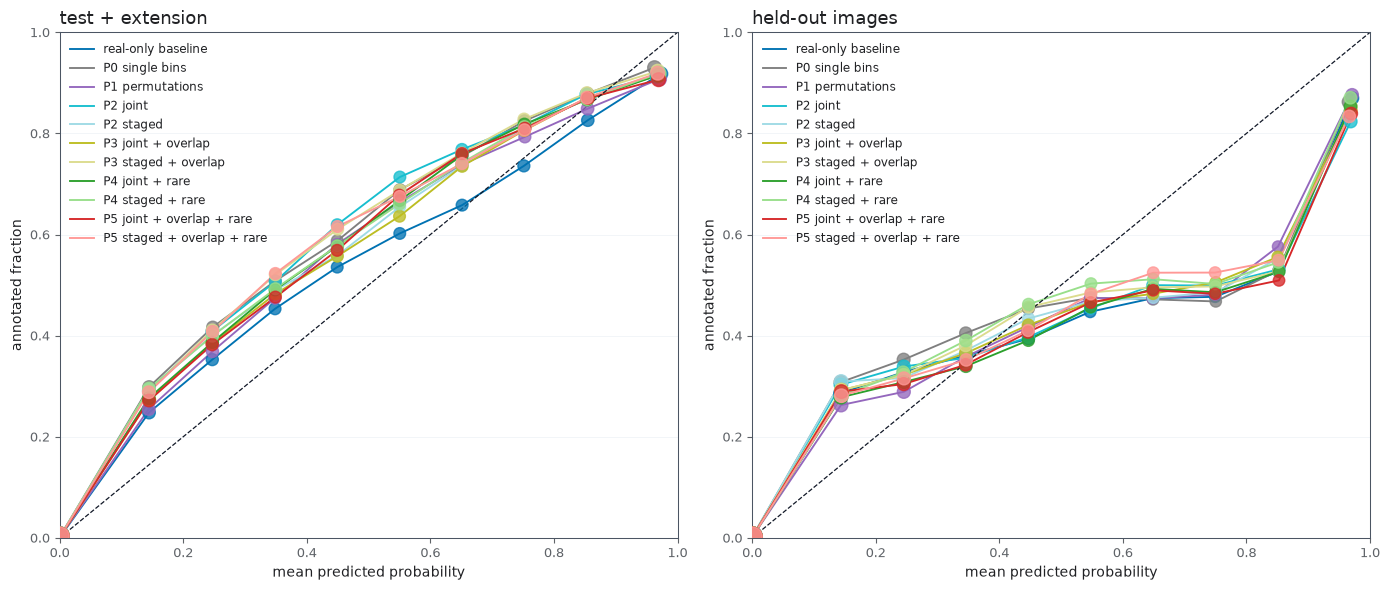

In [10]:
bins = table('calibration_bins')
figure, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=theme.figure_dpi)
for ax, evaluation in zip(axes, ['test_combined', 'heldout_image']):
    figures.reliability_diagram(bins[bins.evaluation == evaluation], levels=ORDER, labels=VARIANT_LABELS, colors=VARIANT_COLORS,
                                title=EVALUATION_NAMES[evaluation], ax=ax, theme=theme)
figure.tight_layout()
calibration = table('calibration')
above = (bins[bins.lower >= 0.5].groupby(['variant', 'evaluation']).entries.sum()
         / bins.groupby(['variant', 'evaluation']).entries.sum()).rename('fraction_p_at_least_0.5')
means = calibration.groupby(['variant', 'evaluation'])[['expected_calibration_error', 'brier_score', 'mean_probability', 'positive_rate']].mean()
display(means.join(above).unstack('evaluation').reindex(ORDER).round(4))
calibration_summary = summarize(table('calibration_improvements'), ['variant', 'evaluation', 'metric'])
display(calibration_summary.assign(result=interval(calibration_summary)).pivot_table(index='variant', columns=['metric', 'evaluation'], values='result', aggfunc='first').reindex(VARIANTS))

### Remarks

- test+ext: ECE baseline 0.00643, variants 0.00769-0.00961; fraction of entries with p >= 0.5: baseline 0.0557, variants 0.0511-0.0538.
- held-out: ECE baseline 0.00334, variants 0.00314-0.00352; fraction of entries with p >= 0.5: baseline 0.00374, variants 0.00351-0.0041.

### Notes

## Results / Summary

### LLM

- **Observed:** fraction of entries with p >= 0.5: baseline 0.0115, variants 0.0107-0.0112.
- **Interpretation:** the retrained head behaves like the baseline head: whole-axis, per-image and per-stratum AP differ by at most a few hundredths; calibration is comparable. At 0.5 the micro precision is higher for 10 and the micro recall lower for 10 of 10 variants (test + extension), i.e. the retrained heads are slightly more conservative, which lowers F1.

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- macro AP, test_combined: baseline 0.7088; others 0.7063-0.7124; 6 of 10 better than the baseline; best P3 staged + overlap (0.7124), worst P1 permutations (0.7063).
- micro AP, test_combined: baseline 0.8828; others 0.8717-0.886; 1 of 10 better than the baseline; best P0 single bins (0.886), worst P5 joint + overlap + rare (0.8717).
- micro recall at 0.5, test_combined: baseline 0.8063; others 0.7596-0.7905; 0 of 10 better than the baseline; best P1 permutations (0.7905), worst P3 staged + overlap (0.7596).
- macro AP, heldout_image: baseline 0.3557; others 0.3413-0.3527; 0 of 10 better than the baseline; best P1 permutations (0.3527), worst P2 staged (0.3413).
- micro AP, heldout_image: baseline 0.5924; others 0.5701-0.5943; 1 of 10 better than the baseline; best P4 staged + rare (0.5943), worst P2 staged (0.5701).
- micro recall at 0.5, heldout_image: baseline 0.3063; others 0.295-0.3339; 7 of 10 better than the baseline; best P5 staged + overlap + rare (0.3339), worst P1 permutations (0.295).

### Person